In [1]:
"""
    Import packages for data management (pandas) and plotting (matplotlib)
"""

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
"""
    Fetch limit curve from path; return an error message if the path is missing/incorrect
"""

input=Path("data/processed/limit_curve.csv")
output=Path("plots/limit_curve.png")

if not input.exists():
    print(f"Missing input file: {input}")
    print("insert in (input) actual csv pls, then run this script again.")
    raise SystemExit

In [3]:
"""
    Convert the limit curve csv file to pandas object and read masses and limits
"""

data=pd.read_csv(input,comment="#")
mass=data["mass_GeV"]
upper_limit=data["upper_limit"]

Plot saved to plots\limit_curve.png


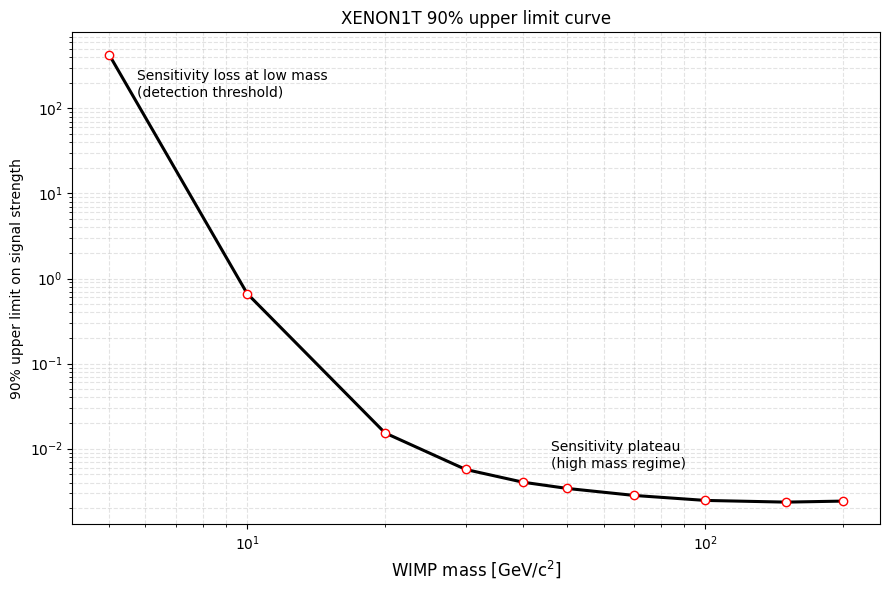

In [4]:
"""
    Show logarithmic plot of 90% upper limit curve against WIMP mass
    Enable annotations for better readability
"""

plt.figure(figsize=(9,6))
plt.plot(mass,upper_limit,marker="o",color="black",markerfacecolor="white",markeredgecolor="red",linewidth=2.2,markersize=6)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("WIMP mass [GeV/c$^2$]",fontsize=12)
plt.ylabel("90% upper limit on signal strength")
plt.title("XENON1T 90% upper limit curve")
plt.grid(True,which="both",linestyle="--",alpha=0.35)
plt.annotate( "Sensitivity plateau\n(high mass regime)", xy=(mass.iloc[6],upper_limit.iloc[6]), xytext=(-60,20),textcoords="offset points",fontsize=10)
plt.annotate( "Sensitivity loss at low mass\n(detection threshold)", xy=(mass.iloc[0],upper_limit.iloc[0]), xytext=(20,-30),textcoords="offset points",fontsize=10)
plt.tight_layout()
plt.savefig(output,dpi=300,bbox_inches="tight")

print(f"Plot saved to {output}")
plt.show()